Using CPU. Note: This module is much faster with a GPU.
/var/folders/g2/k1mz5gnx5hl_kfndvc_v6s6h0000gn/T/ipykernel_67864/1464779646.py:18: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kakasi_converter.setMode("J", "H")
/var/folders/g2/k1mz5gnx5hl_kfndvc_v6s6h0000gn/T/ipykernel_67864/1464779646.py:19: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kakasi_converter.setMode("K", "H")
/var/folders/g2/k1mz5gnx5hl_kfndvc_v6s6h0000gn/T/ipykernel_67864/1464779646.py:20: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kakasi_converter.setMode("H", "H")
/var/folders/g2/k1mz5gnx5hl_kfndvc_v6s6h0000gn/T/ipykernel_67864/1464779646.py:21: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kakasi_

▶ 후리가나 삽입 결과 (문장 단위):

んしう
問題(もんだい)5
つぎのいとに2の文章(ぶんしょう)を読ん(よん)で、質問(しつもん)に答え(こたえ)なさい
答え(こたえ)は、
1・2・3・4から
最も(もっとも)よいものを一(いち)つえらびなさい
川(かわ)
私(わたし)は本(ほん)が好き(すき)で、
よく本(ほん)を買う(かう)のですが、
先日(せんじつ)失敗(しっぱい)をしてしまいました家(いえ)で買っ(かっ)たば
かりの本(ほん)を読ん(よん)でいたら、前(まえ)に読ん(よん)だことがあるような気(き)がしてきたのです。
もしかした
ほ
ら持っ(もっ)ている本(ほん)かもしれないと思っ(おもっ)て本棚(ほんだな)を探し(さがし)てみたら、やっぱりありました。
そして、
その本(ほん)を読ん(よん)だことも思い出し(おもいだし)たのです
1
私(わたし)はたまにこんな失敗(しっぱい)をします。
読ん(よん)だことがある本(ほん)なのに、買っ(かっ)たことも内容(ないよう)も定れ(ていれ)
ているのです。
それが面白く(おもしろく)ない本(ほん)だったときは、
つまらない本(ほん)のために二(に)度(ど)もお金(きん)を払っ(はらっ)たことが梅(うめ)
しくなります。
でも、面白く(おもしろく)て感動(かんどう)した本(ほん)だったときには、梅(うめ)しいだけではなく自分(じぶん)が嫌(いや)
になります。
いいと恩(おん)った本(ほん)のことをわれてしまった白(しろ)分(ふん)が情けない(なさけない)のです。
これからも同じ(おなじ)ようなことをしてしまうかもしれません。
でも本(ほん)を読む(よむ)のは楽しい(たのしい)の
で本屋(ほんや)通い(かよい)はやめられそうもありません。


/var/folders/g2/k1mz5gnx5hl_kfndvc_v6s6h0000gn/T/ipykernel_67864/1464779646.py:64: DeprecationWarning: Call to deprecated method do. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  reading = conv.do(surface)


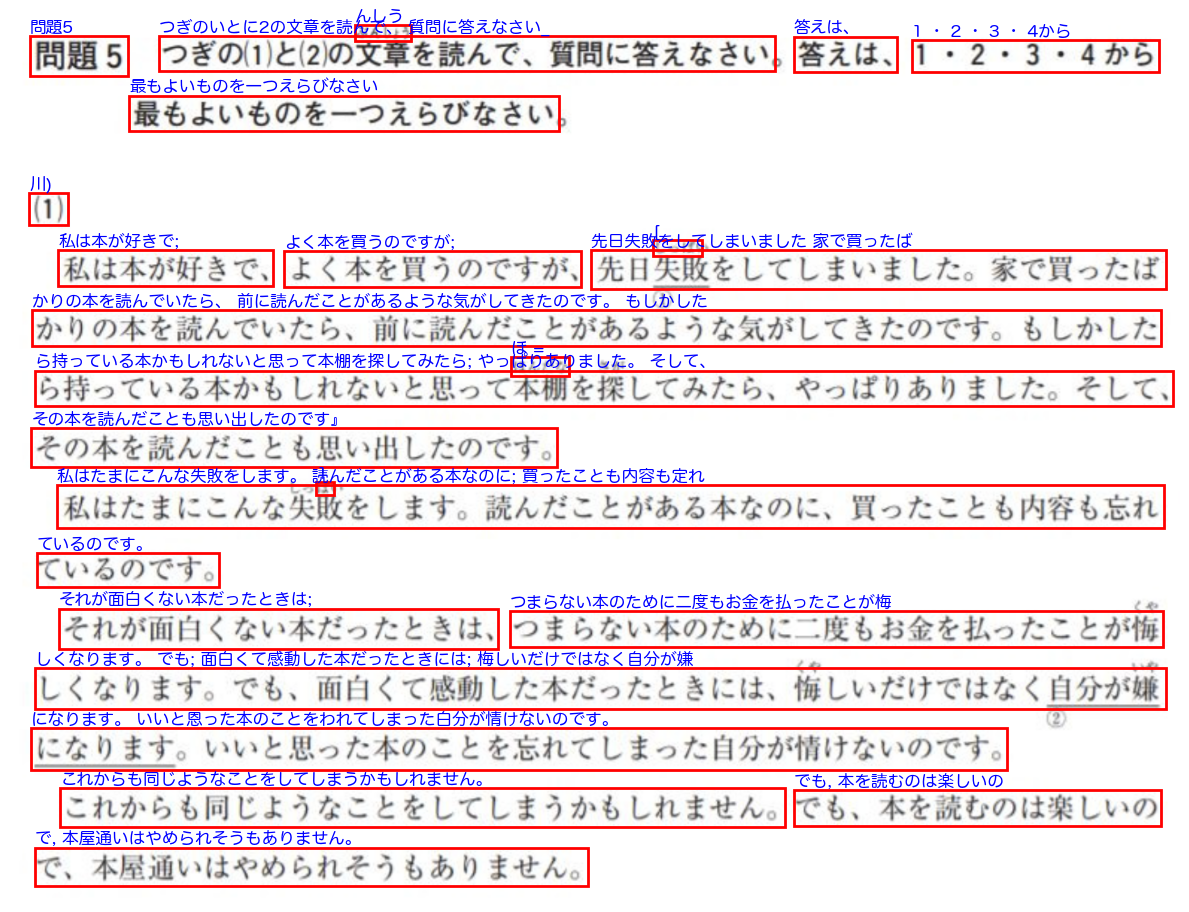

In [25]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams
from easyocr import Reader
from fugashi import Tagger
from pykakasi import kakasi
import re

# ✅ 일본어 폰트 설정 (macOS 기준, 다른 시스템은 적절히 교체)
rcParams['font.family'] = 'Hiragino Maru Gothic Pro'

# ✅ OCR / 형태소 분석기 / 변환기 초기화
reader = Reader(['ja'], gpu=False)
tagger = Tagger()
kakasi_converter = kakasi()
kakasi_converter.setMode("J", "H")  # 한자 → 히라가나
kakasi_converter.setMode("K", "H")  # 가타카나 → 히라가나
kakasi_converter.setMode("H", "H")  # 히라가나 유지
kakasi_converter.setMode("r", "Hepburn")
conv = kakasi_converter.getConverter()

# ✅ 이미지 로드
IMAGE_PATH = "sample/sample3.png"
image = Image.open(IMAGE_PATH).convert("RGB")
image_np = np.array(image)

# ✅ OCR 수행
results = reader.readtext(image_np, detail=1)

# ✅ 후리가나 변환 함수
def insert_furigana(text: str) -> str:
    result = []
    for word in tagger(text):
        surface = word.surface
        if surface.strip() == "":
            continue
        if re.search(r'[\u4e00-\u9faf]', surface):
            reading = conv.do(surface)
            result.append(f"{surface}({reading})")
        else:
            result.append(surface)
    return ''.join(result)

# ✅ 출력
print("▶ OCR 인식 결과:")
for _, text, conf in results:
    print(f"{text} ({conf:.2f})")

print("\n▶ 후리가나 삽입 결과:\n")

for _, text, _ in results:
    # ✅ 정규화: 쉼표 및 마침표 교정
    text = text.replace(";", "、")
    text = text.replace(",", "、")
    text = text.replace(".", "。")

    # ✅ 불필요한 특수문자 제거 (숫자, 일본어, 쉼표/마침표 제외)
    text = re.sub(r"[^\u3040-\u30FF\u4E00-\u9FAF。、0-9a-zA-Z\s]", "", text)

    # ✅ 후리가나 출력
    if text.strip():
        print(insert_furigana(text))

# ✅ 시각화
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(image_np)

for bbox, text, _ in results:
    (tl, tr, br, bl) = bbox
    x = min(pt[0] for pt in [tl, tr, br, bl])
    y = min(pt[1] for pt in [tl, tr, br, bl])
    width = max(pt[0] for pt in [tl, tr, br, bl]) - x
    height = max(pt[1] for pt in [tl, tr, br, bl]) - y

    rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 5, text, color='blue', fontsize=12, weight='bold')

plt.axis("off")
plt.tight_layout()
plt.show()